In [1]:
# --- Core imports ---
from pathlib import Path
import numpy as np
import pandas as pd
import joblib

In [ ]:
# Load ml_df_v4
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "ml_df_v4.csv").exists() and (ROOT.parent / "data" / "ml_df_v4.csv").exists():
    ROOT = ROOT.parent

ml_df = pd.read_csv(ROOT / "data" / "ml_df_v4.csv")
if "date" in ml_df.columns:
    ml_df["date"] = pd.to_datetime(ml_df["date"], errors="coerce")

# Add ranking_diff if ranking scores exist
if "home_ranking_score" in ml_df.columns and "away_ranking_score" in ml_df.columns:
    ml_df["ranking_diff"] = ml_df["home_ranking_score"] - ml_df["away_ranking_score"]

print("ml_df_v4 shape:", ml_df.shape)
ml_df[["year", "home_team", "away_team", "home_wc_goals_before", "away_wc_goals_before", "result_target"]].head()

ml_df_v4 shape: (862, 186)


,year,home_team,away_team,home_wc_goals_before,away_wc_goals_before,result_target
0,1930,France,Mexico,0,0,HomeWin
1,1930,United States,Belgium,0,0,HomeWin
2,1930,Romania,Peru,0,0,HomeWin
3,1930,Yugoslavia,Brazil,0,0,HomeWin
4,1930,Argentina,France,0,4,HomeWin


## No-Leakage Validation

Exclude post-match fields; include new player features.

In [ ]:
# Define feature columns
LEAKAGE_COLS = {
    "home_goals", "away_goals", "score", "result",
    "home_team_win", "away_team_win", "draw",
    "extra_time", "penalty_shootout", "score_penalties",
}

CATEGORICAL_COLS = [
    "stage", "tournament_name", "host_country",
    "home_team", "away_team", "tournament_size_category",
]

ENGINEERED_PREFIXES = ["home_", "away_"]

# Explicit diff/context columns (player features picked up via home_/away_ prefixes)
# v4 adds: is_neutral_venue, home_advantage_strength
EXPLICIT_COLS = [
    "win_rate_diff", "goal_diff_diff", "form_diff",
    "goals_per_match_diff", "conceded_per_match_diff",
    "season_win_rate_diff", "season_goal_diff_diff",
    "elo_diff", "ranking_diff", "wc_goals_diff_before",
    "total_teams", "matches_played", "goals_scored_tournament",
    "avg_goals_per_game", "year_normalized",
    "is_neutral_venue", "home_advantage_strength",
]

feature_cols = [
    c for c in ml_df.columns
    if (
        c in CATEGORICAL_COLS
        or any(c.startswith(p) for p in ENGINEERED_PREFIXES)
        or c in EXPLICIT_COLS
    )
]
feature_cols = [c for c in feature_cols if c not in LEAKAGE_COLS and c != "result_target"]

# --- Phase 1: Leakage Audit Assertions ---
assert set(feature_cols) & LEAKAGE_COLS == set(), "Leakage detected: features overlap with LEAKAGE_COLS"
forbidden_substrings = ["_after", "_post"]
suspicious = [c for c in feature_cols if any(f in c.lower() for f in forbidden_substrings)]
assert len(suspicious) == 0, f"Suspicious post-match-like features: {suspicious}"

print("Leakage in features:", set(feature_cols) & LEAKAGE_COLS)
print("Feature count:", len(feature_cols))
print("Leakage audit: PASSED (no LEAKAGE_COLS, no _after/_post)")

Leakage in features: set()
Feature count: 161
Leakage audit: PASSED (no LEAKAGE_COLS, no _after/_post)


## Time-Aware Split

Split by tournament year to avoid leakage.

In [5]:
# --- Time-Aware Split ---
ml_df = ml_df.sort_values("date").reset_index(drop=True)

train_df = ml_df[ml_df["year"] <= 2014]
val_df = ml_df[ml_df["year"] == 2018]
test_df = ml_df[ml_df["year"] == 2022]

print("Train:", train_df.shape, train_df["year"].min(), "-", train_df["year"].max())
print("Val:", val_df.shape, val_df["year"].min(), "-", val_df["year"].max())
print("Test:", test_df.shape, test_df["year"].min(), "-", test_df["year"].max())

X_train = train_df[feature_cols]
y_train = train_df["result_target"]
X_val = val_df[feature_cols]
y_val = val_df["result_target"]
X_test = test_df[feature_cols]
y_test = test_df["result_target"]

Train: (736, 186) 1930 - 2014
Val: (62, 186) 2018 - 2018
Test: (64, 186) 2022 - 2022


## Model Training and Comparison

Train LogReg, RF, XGBoost, LightGBM; pick best by validation log loss.

In [6]:
# --- Build preprocessor and train multiple models ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, HistGradientBoostingRegressor

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False
try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False


def build_preprocessor(X: pd.DataFrame):
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
    num_pipe = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(
        transformers=[("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)]
    )


CLASS_ORDER = ["HomeWin", "Draw", "AwayWin"]
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)
CLASS_ORDER_ENC = list(label_encoder.transform(CLASS_ORDER))
y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

preprocessor = build_preprocessor(X_train)

models = {
    "LogReg": LogisticRegression(max_iter=3000, multi_class="multinomial", class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42),
}
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        objective="multi:softprob", eval_metric="mlogloss",
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.9, colsample_bytree=0.9, reg_alpha=1.0, reg_lambda=2.0, random_state=42,
    )
if LGBM_AVAILABLE:
    models["LightGBM"] = LGBMClassifier(objective="multiclass", n_estimators=400, learning_rate=0.05, max_depth=5, reg_alpha=1.0, reg_lambda=2.0, class_weight="balanced", random_state=42)
else:
    models["HistGB"] = HistGradientBoostingClassifier(random_state=42)

# Train all models and evaluate on validation
results = []
model_store = {}
for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    if name == "XGBoost":
        pipe.fit(X_train, y_train_enc)
        proba = pipe.predict_proba(X_val)
        ll = log_loss(y_val_enc, proba)
    else:
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_val)
        ll = log_loss(y_val, proba)
    results.append({"model": name, "log_loss": ll})
    model_store[name] = pipe

results_df = pd.DataFrame(results).sort_values("log_loss")
best_model_name = results_df.iloc[0]["model"]
best_model = model_store[best_model_name]
print("Best model by log loss:", best_model_name)
results_df

/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7991
[LightGBM] [Info] Number of data points in the train set: 736, number of used features: 236
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,log_loss
2,XGBoost,0.269602
3,LightGBM,0.278656
1,RandomForest,0.583959
0,LogReg,0.958966


/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/Users/jeanphilippeauguste/Downloads/Techlabs Dusseldorf Data Science/work/.venv/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Log loss: raw=0.2696 sigmoid=0.3388 isotonic=0.1490 -> using isotonic
Brier: raw=0.4955 sigmoid=0.4499 isotonic=0.5127


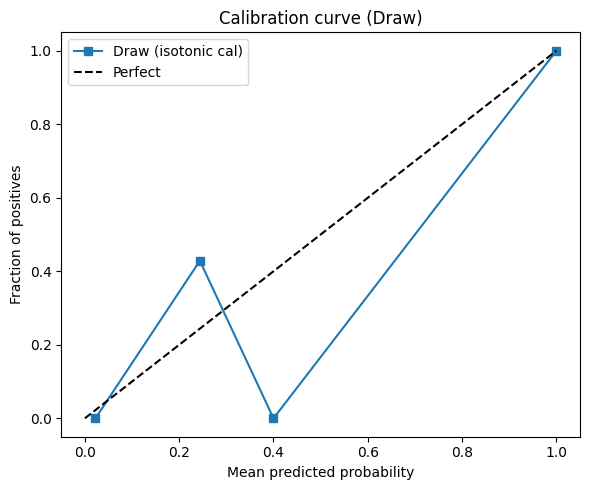

In [7]:
# --- Phase 2: Probability calibration (Brier, curves, sigmoid vs isotonic) ---
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

order_cal = CLASS_ORDER_ENC if best_model_name == "XGBoost" else CLASS_ORDER
y_te_cal = y_val_enc if best_model_name == "XGBoost" else y_val
base_proba = best_model.predict_proba(X_val)
base_log_loss = log_loss(y_val_enc, base_proba) if best_model_name == "XGBoost" else log_loss(y_val, base_proba)
base_brier = np.mean([brier_score_loss((y_te_cal == c).astype(int), base_proba[:, i]) for i, c in enumerate(order_cal)])

# Sigmoid calibration
calibrated = CalibratedClassifierCV(best_model, method="sigmoid", cv="prefit")
if best_model_name == "XGBoost":
    calibrated.fit(X_val, y_val_enc)
    cal_proba = calibrated.predict_proba(X_val)
    cal_log_loss = log_loss(y_val_enc, cal_proba)
else:
    calibrated.fit(X_val, y_val)
    cal_proba = calibrated.predict_proba(X_val)
    cal_log_loss = log_loss(y_val, cal_proba)
cal_brier = np.mean([brier_score_loss((y_te_cal == c).astype(int), cal_proba[:, i]) for i, c in enumerate(order_cal)])

# Isotonic calibration (alternative)
calibrated_iso = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
if best_model_name == "XGBoost":
    calibrated_iso.fit(X_val, y_val_enc)
    iso_proba = calibrated_iso.predict_proba(X_val)
    iso_log_loss = log_loss(y_val_enc, iso_proba)
else:
    calibrated_iso.fit(X_val, y_val)
    iso_proba = calibrated_iso.predict_proba(X_val)
    iso_log_loss = log_loss(y_val, iso_proba)
iso_brier = np.mean([brier_score_loss((y_te_cal == c).astype(int), iso_proba[:, i]) for i, c in enumerate(order_cal)])

# Pick best: raw, sigmoid, or isotonic by log loss
candidates = [
    ("raw", best_model, base_proba, base_log_loss, base_brier),
    ("sigmoid", calibrated, cal_proba, cal_log_loss, cal_brier),
    ("isotonic", calibrated_iso, iso_proba, iso_log_loss, iso_brier),
]
best_name, final_model, best_proba, best_ll, best_br = min(candidates, key=lambda x: x[3])
print("Log loss: raw={:.4f} sigmoid={:.4f} isotonic={:.4f} -> using {}".format(base_log_loss, cal_log_loss, iso_log_loss, best_name))
print("Brier: raw={:.4f} sigmoid={:.4f} isotonic={:.4f}".format(base_brier, cal_brier, iso_brier))

# Calibration curve plot (one class: Draw)
fig, ax = plt.subplots(figsize=(6, 5))
idx = CLASS_ORDER.index("Draw")
y_bin = (y_val.values == "Draw").astype(int) if best_model_name != "XGBoost" else (y_val_enc == CLASS_ORDER_ENC[idx]).astype(int)
prob_col = best_proba[:, idx]
frac_pos, mean_pred = calibration_curve(y_bin, prob_col, n_bins=5)
ax.plot(mean_pred, frac_pos, "s-", label="Draw ({} cal)".format(best_name))
ax.plot([0, 1], [0, 1], "k--", label="Perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curve (Draw)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# --- Test set metrics ---
y_te = y_test_enc if best_model_name == "XGBoost" else y_test
test_proba = final_model.predict_proba(X_test)
test_pred = final_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_te, test_pred))
print("Test log loss:", log_loss(y_te, test_proba))

Test accuracy: 0.921875
Test log loss: 1.2734364442047978


In [9]:
# --- Score prediction (home/away goals for Monte Carlo) ---
import sys
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from sklearn.preprocessing import FunctionTransformer
from analysis.ml_utils import to_dense_fn

to_dense = FunctionTransformer(to_dense_fn, accept_sparse=True)

y_home = train_df["home_goals"]
y_away = train_df["away_goals"]

reg_home = Pipeline(steps=[
    ("prep", preprocessor),
    ("to_dense", to_dense),
    ("model", HistGradientBoostingRegressor(random_state=42)),
])
reg_away = Pipeline(steps=[
    ("prep", preprocessor),
    ("to_dense", to_dense),
    ("model", HistGradientBoostingRegressor(random_state=42)),
])
reg_home.fit(X_train, y_home)
reg_away.fit(X_train, y_away)

# --- Score-first: evaluate score models and derive outcome from scores ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
pred_home_test = np.clip(reg_home.predict(X_test), 0, None)
pred_away_test = np.clip(reg_away.predict(X_test), 0, None)
mae_home = mean_absolute_error(test_df["home_goals"], pred_home_test)
mae_away = mean_absolute_error(test_df["away_goals"], pred_away_test)
rmse_home = np.sqrt(mean_squared_error(test_df["home_goals"], pred_home_test))
rmse_away = np.sqrt(mean_squared_error(test_df["away_goals"], pred_away_test))
print("Score models fitted.")
print("Test MAE: home={:.3f} away={:.3f} | RMSE: home={:.3f} away={:.3f}".format(mae_home, mae_away, rmse_home, rmse_away))

# Derive outcome from predicted scores (score-first: win/lose from score as in real game)
def score_to_outcome(pred_h, pred_a):
    h, a = int(np.round(np.clip(pred_h, 0, 10))), int(np.round(np.clip(pred_a, 0, 10)))
    return "HomeWin" if h > a else ("AwayWin" if a > h else "Draw")
pred_outcome_from_score = [score_to_outcome(h, a) for h, a in zip(pred_home_test, pred_away_test)]
score_derived_acc = accuracy_score(y_test, pred_outcome_from_score)
print("Score-derived outcome accuracy (test): {:.2%}".format(score_derived_acc))

Score models fitted.
Test MAE: home=0.585 away=0.529 | RMSE: home=0.790 away=0.716
Score-derived outcome accuracy (test): 67.19%


In [10]:
# --- Save artifact ---
# Score-first: score_models are primary; outcome derived from predicted scores.
# Outcome model retained for probability calibration and Monte Carlo.
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": final_model,
    "feature_cols": feature_cols,
    "class_order": CLASS_ORDER,
    "score_models": {"home_goals": reg_home, "away_goals": reg_away},
    "primary_prediction": "score",  # Use score-derived outcome as primary; outcome model for probs
}

artifact_path = MODELS_DIR / "worldcup_model_v4.joblib"
joblib.dump(artifact, artifact_path)

# --- Phase 4: Reproducibility check ---
loaded = joblib.load(artifact_path)
pred_reload = loaded["model"].predict(X_test)
assert np.array_equal(np.asarray(pred_reload), np.asarray(test_pred)), "Reload mismatch: n4.21 test_pred != loaded model predict"
# Score-derived reproducibility
rh, ra = loaded["score_models"]["home_goals"], loaded["score_models"]["away_goals"]
ph = np.clip(rh.predict(X_test), 0, None)
pa = np.clip(ra.predict(X_test), 0, None)
pred_score_reload = [score_to_outcome(h, a) for h, a in zip(ph, pa)]
assert pred_score_reload == pred_outcome_from_score, "Score-derived reload mismatch"
print("Saved:", artifact_path)
print("Reproducibility: PASSED (outcome + score-derived)")

Saved: /Users/jeanphilippeauguste/Downloads/DS4-World-Cup-Project-Phase/models/worldcup_model_v4.joblib
Reproducibility: PASSED (outcome + score-derived)
